In [ ]:
# Cellule d'import : On importe tout ici dans cette cellule pour garder le notebook propre.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Configuration visuelle globale
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Chargement du dataset
# Le fichier est placé dans le dossier data/ à la racine du projet
df = pd.read_csv("data/etrilabs_sante_maternelle_pf.csv")

# Premier regard sur les données : dimensions et premières lignes
print(f"Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()

Dataset chargé : 1200 lignes, 16 colonnes


,id_enquete,pays,region_departement,milieu,age_annees,niveau_instruction,langue_principale,distance_centre_sante_km,nb_consultations_prenatales,utilisation_contraceptif_moderne,accouchement_assiste_professionnel,nb_enfants_vivants,revenu_mensuel_menage_fcfa,connaissance_service_pf,visite_agent_sante_communautaire_6mois,satisfaction_service_sante_1a5
0,ENQ-0001,Bénin,Borgou,Péri-urbain,45,Primaire,Yoruba,0.6,1.0,0.0,0,1,115353.0,0,0,5
1,ENQ-0002,Sénégal,Dakar,Urbain,41,Secondaire,Wolof,1.3,3.0,0.0,1,0,53817.0,1,1,1
2,ENQ-0003,Sénégal,Kolda,Rural,25,Secondaire,Autre,18.4,3.0,1.0,1,4,18436.0,1,0,5
3,ENQ-0004,Sénégal,Saint-Louis,Rural,19,Aucun,Autre,10.5,2.0,0.0,1,4,NaN,1,0,2
4,ENQ-0005,Bénin,Mono,Rural,22,Aucun,Fon,1.0,1.0,0.0,0,4,21156.0,1,0,4


#### 1. Chargement des données

Le dataset porte sur la santé maternelle en Afrique de l'Ouest. Il contient des informations
sur le profil socio-démographique des femmes, leur accès aux soins, et leurs comportements
de santé reproductive. Notre variable cible pour la modélisation sera
`accouchement_assiste_professionnel` — un indicateur binaire (0/1) qui traduit directement
le risque d'accouchement sans assistance médicale.

In [3]:
#on prend le temps de bien comprendre ce qu'on a; les valeurs manquantes, et les distributions des variables clés. 
print("=== Informations générales ===")
print(df.info())

print("\n=== Valeurs manquantes par colonne ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Aucune valeur manquante détectée")

print("\n=== Statistiques descriptives (variables numériques) ===")
df.describe().round(2)

=== Informations générales ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 16 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id_enquete                              1200 non-null   object 
 1   pays                                    1200 non-null   object 
 2   region_departement                      1200 non-null   object 
 3   milieu                                  1200 non-null   object 
 4   age_annees                              1200 non-null   int64  
 5   niveau_instruction                      1200 non-null   object 
 6   langue_principale                       1200 non-null   object 
 7   distance_centre_sante_km                1117 non-null   float64
 8   nb_consultations_prenatales             1116 non-null   float64
 9   utilisation_contraceptif_moderne        1134 non-null   float64
 10  accouchement_assiste_professi

,age_annees,distance_centre_sante_km,nb_consultations_prenatales,utilisation_contraceptif_moderne,accouchement_assiste_professionnel,nb_enfants_vivants,revenu_mensuel_menage_fcfa,connaissance_service_pf,visite_agent_sante_communautaire_6mois,satisfaction_service_sante_1a5
count,1200.00,1117.00,1116.00,1134.00,1200.00,1200.00,1047.00,1200.00,1200.00,1200.00
mean,32.08,8.39,2.20,0.30,0.60,3.60,121528.93,0.56,0.43,3.84
std,10.03,10.40,1.72,0.46,0.49,2.02,398519.03,0.50,0.50,7.38
min,15.00,0.50,0.00,0.00,0.00,0.00,3566.00,0.00,0.00,1.00
25%,24.00,1.60,1.00,0.00,0.00,2.00,30044.00,0.00,0.00,2.00
50%,32.00,4.20,2.00,0.00,1.00,3.00,56846.00,1.00,0.00,3.00
75%,41.00,11.40,3.00,1.00,1.00,5.00,117159.50,1.00,1.00,4.00
max,49.00,80.00,8.00,1.00,1.00,11.00,6744311.00,1.00,1.00,99.00


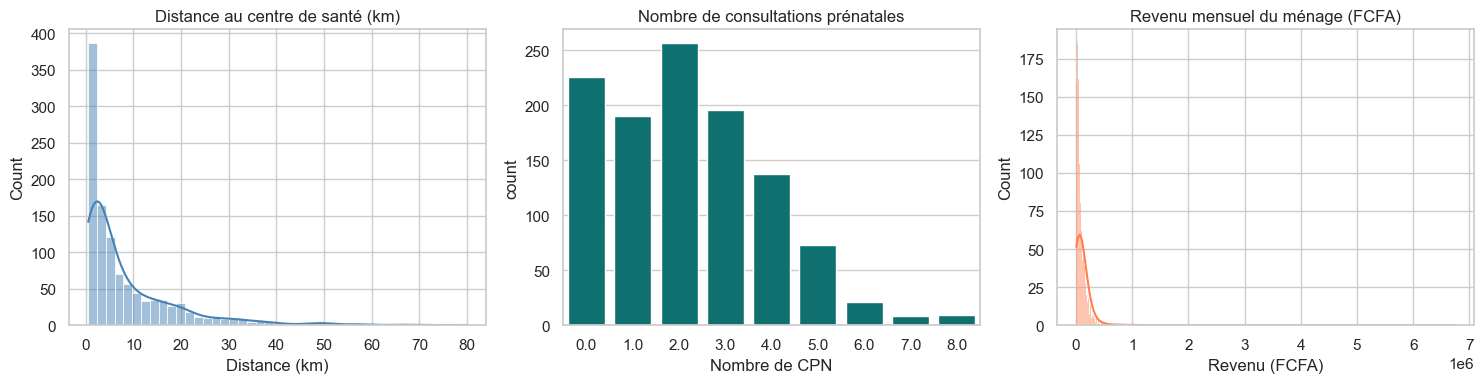


=== Répartition de la variable cible ===
accouchement_assiste_professionnel
1    60.0
0    40.0
Name: proportion, dtype: float64


In [5]:
# On visualise les variables les plus importantes pour notre problématique :
# la distance au centre de santé, le nombre de CPN, et le revenu du ménage.
# Ces trois variables sont au coeur de nos hypothèses terrain.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution de la distance au centre de santé
sns.histplot(df['distance_centre_sante_km'], ax=axes[0], color='steelblue', kde=True)
axes[0].set_title("Distance au centre de santé (km)")
axes[0].set_xlabel("Distance (km)")

# Distribution du nombre de consultations prénatales
sns.countplot(x='nb_consultations_prenatales', data=df, ax=axes[1], color='teal')
axes[1].set_title("Nombre de consultations prénatales")
axes[1].set_xlabel("Nombre de CPN")

# Distribution du revenu mensuel du ménage
sns.histplot(df['revenu_mensuel_menage_fcfa'], ax=axes[2], color='coral', kde=True)
axes[2].set_title("Revenu mensuel du ménage (FCFA)")
axes[2].set_xlabel("Revenu (FCFA)")

plt.tight_layout()
plt.savefig("figures/distributions_cles.png", dpi=150)
plt.show()

# Distribution de notre variable cible
print("\n=== Répartition de la variable cible ===")
print(df['accouchement_assiste_professionnel'].value_counts(normalize=True).round(3) * 100)

#### 2b. Distributions des variables clés

Le dataset contient **1200 observations** et **16 variables**. Quelques points importants
avant d'aller plus loin :

**Valeurs manquantes à noter :**
- `distance_centre_sante_km` : 83 valeurs manquantes (6.9%)
- `nb_consultations_prenatales` : 84 valeurs manquantes (7%)
- `revenu_mensuel_menage_fcfa` : 153 valeurs manquantes (12.75%), la plus affectée
- Ces valeurs manquantes ne sont probablement pas aléatoires : ce sont souvent
  les femmes les plus précaires qui n'ont pas déclaré leur revenu. On en tiendra
  compte lors du preprocessing.

**Sur les distributions observées :**
- La distance est fortement asymétrique majorité des femmes à moins de 5km,
  mais une queue jusqu'à 80km. Une transformation logarithmique sera appliquée.
- Le nombre de CPN est préoccupant : beaucoup de femmes à 0 ou 1 consultation,
  loin du seuil recommandé de 4 par l'OMS.
- Le revenu est extrêmement concentré vers les faibles valeurs transformation
  logarithmique également nécessaire.

**Variable cible :** 60% des accouchements sont assistés par un professionnel,
40% ne le sont pas. Le dataset est relativement équilibré pas besoin de
rééchantillonnage, mais on restera attentif aux métriques au-delà de la simple accuracy.